# Relative Acceleration Threshold (relthreshold₇₅%)

Attempts to implement the methodology from:
> Bielmann et al. (2026). *Assessing High-Intensity Acceleration Efforts Using Local Positioning System—Introducing the Concept of the Relative Acceleration Threshold to Ice Hockey.* Sports, 14(2), 62. https://doi.org/10.3390/sports14020062

*Note*: I was not able to complete this in time for my paper submission but I'm still very interested in this angle.

## Rationale
A fixed 2 m/s² threshold (`fixthreshold_2`) treats a 2 m/s² burst from a standing start the same as one from 25 km/h — but the latter is far closer to the neuromuscular limit.  The **relative threshold** method accounts for the inverse linear relationship between initial speed (v_init) and maximal voluntary acceleration capacity (a_max).

## Algorithm summary
1. **Detect discrete accefforts** via the zero-crossing method: start when acceleration turns positive, end when it returns to ≤ 0.  Apply a *dip rule* to split efforts separated by a low-accel pause.  Filter by minimum duration (1.15 s) and speed gain (1 m/s).
2. **Model individual a_max–v_init capacity**: select the top-4 accefforts per 1 m/s speed bin (0–6 m/s), fit OLS, remove 95%-PI outliers, refit.
3. **Team-level threshold**: average individual regression coefficients, take 75% → `relthreshold_75%`.
4. **Compare** fixthreshold_2 vs relthreshold_75% by count, speed band, and position.

## Unit notes
Paper uses **m/s** and **m/s²**.  Our tracking data uses mph and mph/s.  All conversions apply `× 0.44704`.

In [29]:
import sys, warnings
sys.path.insert(0, str(__import__('pathlib').Path('.').resolve()))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import t as t_dist

from build_shift_df import POS_COLORS, FPS

OUTPUT_DIR = __import__('pathlib').Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# Unit conversion
MPH_TO_MS  = 0.44704   # mph → m/s
MPHPS_TO_MS2 = 0.44704  # mph/s → m/s²

# Algorithm parameters (paper values)
DIP_THRESH_MS2   = 0.5     # m/s² — dip rule threshold
DIP_FRAMES       = 8       # scaled from paper's 5 @ 20 Hz → 8 @ 30 fps (≈0.25 s)
MIN_DURATION_S   = 1.15    # s — minimum acceffort duration
MIN_VDELTA_MS    = 1.0     # m/s — minimum speed gain (= 3.6 km/h)
MIN_FRAMES       = int(np.ceil(MIN_DURATION_S * FPS))  # = 35 frames

# Threshold values (paper: relthreshold_75% = 3.23 − 0.365·v_init)
FIX_THRESH_MS2   = 2.0     # m/s² — traditional fixed threshold

# Speed band edges (m/s) for modeling and reporting
BIN_EDGES_MODEL = [0, 1, 2, 3, 4, 5, 6]   # 1 m/s wide, top-4 per bin for model fitting
BIN_EDGES_REPORT = [0, 2, 4, 6, np.inf]   # very-low, low, moderate, fast
BIN_LABELS_REPORT = ['Very low\n(0–2)', 'Low\n(2–4)', 'Moderate\n(4–6)', 'Fast\n(>6)']

TOP_N_PER_BIN    = 4      # accefforts to select per 1 m/s bin for model fitting
VINIT_MODEL_MAX  = 6.0    # m/s — exclude from model fitting above this speed
RELTHR_FRACTION  = 0.75   # 75% of team mean line

print(f'FPS={FPS}  MIN_FRAMES={MIN_FRAMES}  DIP_FRAMES={DIP_FRAMES}')
print(f'MIN_DURATION={MIN_DURATION_S} s   MIN_VDELTA={MIN_VDELTA_MS} m/s ({MIN_VDELTA_MS/MPH_TO_MS:.2f} mph)')

FPS=30.0  MIN_FRAMES=35  DIP_FRAMES=8
MIN_DURATION=1.15 s   MIN_VDELTA=1.0 m/s (2.24 mph)


## Load tracking data

In [30]:

tracking_raw = pd.read_parquet('../data/tracking.parquet')

# Player rows only — puck has no accel
players = tracking_raw[tracking_raw['Player or Puck'] == 'Player'].copy()

# Convert units
players['speed_ms']   = players['speed_mph_savgol'] * MPH_TO_MS
players['accel_ms2']  = players['accel_mph_s']       * MPHPS_TO_MS2

# Build Game key matching the events/shifts convention (Date + Home @ Away).
# Image Id format: "YYYY-MM-DD Away @ Home_FRAMENUM" — teams are reversed,
# so we swap them to match the Home_Team @ Away_Team convention used by load_tracking.
raw   = players['Image Id'].str.extract(r'^(\d{4}-\d{2}-\d{2}.*?)_\d+$')[0]
parts = raw.str.extract(r'^(\d{4}-\d{2}-\d{2})\s+(.*?)\s+@\s+(.*)$')
players['Game'] = parts[0] + ' ' + parts[2] + ' @ ' + parts[1]  # swap → Home @ Away

# Period as integer
players['Period_int'] = pd.to_numeric(players['Period'], errors='coerce').astype('Int64')

# Clock → elapsed seconds within period (0 = period start, 1200 = end)
def clock_to_elapsed(s):
    try:
        m, c = s.split(':')
        return 1200 - (int(m) * 60 + int(c))
    except Exception:
        return np.nan

players['elapsed_s'] = players['Game Clock'].apply(clock_to_elapsed)

# Drop rows with missing speed/accel
players = players.dropna(subset=['speed_ms', 'accel_ms2'])

# Map tracking's 'Home'/'Away' Team column → actual team names from the Game string.
# Game format: "YYYY-MM-DD Home_Team @ Away_Team"
game_info = players['Game'].str.extract(r'^[\d-]+\s+(.*?)\s+@\s+(.*)$')
players['actual_team'] = np.where(players['Team'] == 'Home', game_info[0], game_info[1])

# Filter out non-numeric jersey numbers (goalies, etc.)
players = players[players['Player Jersey Number'].astype(str).str.match(r'^\d+$')]

# Composite player ID: actual_team + jersey number (matches shift_df convention)
players['team_player'] = players['actual_team'] + '_' + players['Player Jersey Number'].astype(str)

print(f'Player rows:         {len(players):,}')
print(f'Unique team_players: {players["team_player"].nunique()}')
print(f'Games:               {players["Game"].nunique()}')
print(f'Game sample:         {players["Game"].iloc[0]}')
print(f'Team sample:         {players["team_player"].iloc[0]}')


Player rows:         6,769,976
Unique team_players: 258
Games:               10
Game sample:         2025-10-11 Team D @ Team A
Team sample:         Team A_48


## Step 1 — Detect Discrete Acceleration Efforts

### Zero-crossing method
- **Start**: acceleration signal turns positive (crosses 0 upward).
- **End**: signal returns to ≤ 0 m/s².

### Dip rule
If, within a positive-acceleration phase, the signal drops below **0.5 m/s²** for **> 8 consecutive frames** (**≈ 0.25 s**, scaled from 5 frames @ 20 Hz) without turning negative, and then rises again, the effort is **split**: the first effort ends at the dip, and the new v_init for the second effort is the speed immediately preceding the rise.

### Filtering criteria
| Criterion | Paper value | Our equivalent |
|-----------|-------------|----------------|
| `aduration` ≥ 1.15 s | 1.15 s | 35 frames at 30 fps |
| `vdelta` ≥ 3.6 km/h | 1.0 m/s | 2.24 mph |

Segments are split at gaps > 150 frames (5 s) in `frame_id` to avoid bridging bench time.

In [31]:
def _emit_effort(results, start, end, vinit, speed, accel, fps, min_frames, min_vdelta):
    """Validate and append one acceffort."""
    if end <= start or (end - start) < min_frames:
        return
    amax   = float(accel[start:end].max())
    vend   = float(speed[min(end, len(speed) - 1)])
    vdelta = vend - vinit
    if vdelta >= min_vdelta:
        results.append({
            'vinit':    vinit,
            'amax':     amax,
            'aduration': (end - start) / fps,
            'vdelta':   vdelta,
        })


def detect_accefforts_segment(speed, accel, fps=30,
                              dip_thresh=0.5, dip_frames=8,
                              min_frames=35, min_vdelta=1.0):
    """
    Detect discrete accefforts in a single continuous on-ice segment.
    speed, accel: 1-D numpy arrays in m/s and m/s², sorted by frame.
    Returns list of dicts with keys: vinit, amax, aduration, vdelta.
    """
    n = len(accel)
    if n < min_frames:
        return []

    results = []
    i = 0

    while i < n:
        # Find next positive-acceleration frame
        while i < n and accel[i] <= 0:
            i += 1
        if i >= n:
            break

        effort_start = i
        vinit = float(speed[i])

        # Advance through the positive phase, applying the dip rule
        j = i + 1
        in_dip     = False
        dip_start  = None
        dip_count  = 0

        while j < n and accel[j] > 0:
            if accel[j] < dip_thresh:
                # Entering or continuing a dip
                if not in_dip:
                    dip_start = j
                    dip_count = 1
                    in_dip    = True
                else:
                    dip_count += 1
            else:
                # Accel >= dip_thresh again
                if in_dip and dip_count > dip_frames:
                    # Long dip followed by a rise → split effort here
                    _emit_effort(results, effort_start, dip_start, vinit,
                                 speed, accel, fps, min_frames, min_vdelta)
                    # Start a new effort at j; vinit = speed just before the rise
                    effort_start = j
                    vinit        = float(speed[j - 1])
                in_dip    = False
                dip_start = None
                dip_count = 0
            j += 1

        # End of positive phase — emit remaining effort
        if in_dip and dip_count > dip_frames:
            # Effort "ended" at the dip
            _emit_effort(results, effort_start, dip_start, vinit,
                         speed, accel, fps, min_frames, min_vdelta)
        else:
            _emit_effort(results, effort_start, j, vinit,
                         speed, accel, fps, min_frames, min_vdelta)

        i = j if j > effort_start else effort_start + 1

    return results


def detect_all_accefforts(player_df, fps=30,
                           gap_frames=150,       # >5 s gap → bench time
                           dip_thresh=DIP_THRESH_MS2,
                           dip_frames=DIP_FRAMES,
                           min_frames=MIN_FRAMES,
                           min_vdelta=MIN_VDELTA_MS):
    """Run acceffort detection for one player-game-period group."""
    df = player_df.sort_values('frame_id')
    speed = df['speed_ms'].values
    accel = df['accel_ms2'].values
    frames = df['frame_id'].values

    # Split into on-ice segments at large frame_id gaps (bench time)
    gaps = np.diff(frames)
    break_pts = np.where(gaps > gap_frames)[0] + 1  # indices after gap
    seg_starts = np.concatenate([[0], break_pts])
    seg_ends   = np.concatenate([break_pts, [len(df)]])

    all_efforts = []
    for s, e in zip(seg_starts, seg_ends):
        efforts = detect_accefforts_segment(
            speed[s:e], accel[s:e], fps=fps,
            dip_thresh=dip_thresh, dip_frames=dip_frames,
            min_frames=min_frames, min_vdelta=min_vdelta)
        all_efforts.extend(efforts)

    return all_efforts


print('Functions defined. Running detection across all players…')

records = []
for (game, period, team_player), grp in players.groupby(
        ['Game', 'Period_int', 'team_player'], observed=True):
    efforts = detect_all_accefforts(grp)
    for ef in efforts:
        records.append({
            'Game':        game,
            'Period_int':  period,
            'team_player': team_player,
            **ef,
        })

accefforts = pd.DataFrame(records)
print(f'Total accefforts detected: {len(accefforts):,}')
print(f'Unique players:            {accefforts["team_player"].nunique()}')
print(accefforts[['vinit', 'amax', 'aduration', 'vdelta']].describe().round(3))

Functions defined. Running detection across all players…
Total accefforts detected: 2,064
Unique players:            234
          vinit      amax  aduration    vdelta
count  2064.000  2064.000   2064.000  2064.000
mean      1.737     9.774      1.355     4.307
std       1.617     7.463      0.204     1.549
min       0.002     1.316      1.167     1.010
25%       0.452     5.709      1.200     3.210
50%       1.145     7.547      1.300     4.222
75%       2.669    10.860      1.433     5.316
max       8.081    85.889      2.600    12.920


## EDA — Acceffort Cloud

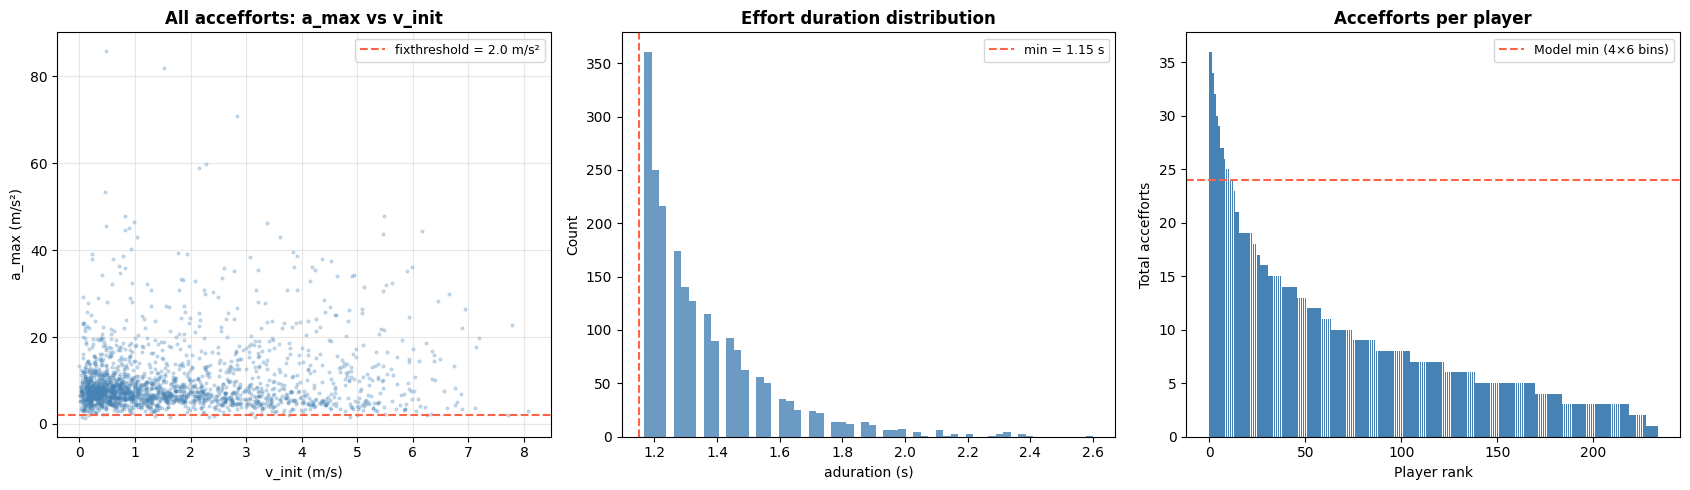

Accefforts per player per game:
count    357.0
mean       5.8
std        3.1
min        1.0
25%        3.0
50%        5.0
75%        7.0
max       16.0
Name: n, dtype: float64


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Panel 1: a_max vs v_init scatter (all players combined) ---
ax = axes[0]
ax.scatter(accefforts['vinit'], accefforts['amax'],
           s=4, alpha=0.25, color='steelblue', rasterized=True)
# Overlay fixed threshold line
v_range = np.linspace(0, accefforts['vinit'].quantile(0.99), 200)
ax.axhline(FIX_THRESH_MS2, color='tomato', lw=1.5, ls='--',
           label=f'fixthreshold = {FIX_THRESH_MS2} m/s²')
ax.set_xlabel('v_init (m/s)')
ax.set_ylabel('a_max (m/s²)')
ax.set_title('All accefforts: a_max vs v_init', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 2: distribution of aduration ---
ax = axes[1]
ax.hist(accefforts['aduration'], bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(MIN_DURATION_S, color='tomato', lw=1.5, ls='--',
           label=f'min = {MIN_DURATION_S} s')
ax.set_xlabel('aduration (s)')
ax.set_ylabel('Count')
ax.set_title('Effort duration distribution', fontweight='bold')
ax.legend(fontsize=9)

# --- Panel 3: accefforts per player (total across all games) ---
ax = axes[2]
n_per_player = accefforts.groupby('team_player').size().sort_values(ascending=False)
ax.bar(range(len(n_per_player)), n_per_player.values, color='steelblue', width=0.8)
ax.axhline(24, color='tomato', lw=1.5, ls='--', label='Model min (4×6 bins)')
ax.set_xlabel('Player rank')
ax.set_ylabel('Total accefforts')
ax.set_title('Accefforts per player', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_eda_accefforts.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-game count
per_game = accefforts.groupby(['team_player', 'Game']).size().reset_index(name='n')
print('Accefforts per player per game:')
print(per_game['n'].describe().round(1))

## Step 2 — Model Individual a_max–v_init Capacity

Procedure (per player, pooling all games):
1. Within each 1 m/s speed subinterval [0–1, 1–2, …, 5–6] select the **top-4** accefforts by `amax`.
2. Fit OLS: `a_max = a0 + a1 · v_init`.
3. Compute 95% prediction intervals; remove outliers outside the PI.
4. Refit on cleaned data → final individual capacity line.

In [33]:
from scipy.stats import t as t_dist

def ols_prediction_interval(x_fit, y_fit, x_new, alpha=0.05):
    """
    95% prediction interval for OLS y = a + b*x.
    Returns (y_pred, pi_lower, pi_upper).
    """
    n      = len(x_fit)
    x_m    = x_fit.mean()
    Sxx    = ((x_fit - x_m) ** 2).sum()
    slope, intercept, _, _, _ = stats.linregress(x_fit, y_fit)
    y_pred  = intercept + slope * x_new
    y_hat   = intercept + slope * x_fit
    mse     = ((y_fit - y_hat) ** 2).sum() / (n - 2)
    se_pred = np.sqrt(mse * (1 + 1/n + (x_new - x_m)**2 / Sxx))
    t_crit  = t_dist.ppf(1 - alpha / 2, df=n - 2)
    return y_pred, y_pred - t_crit * se_pred, y_pred + t_crit * se_pred


def fit_amax_vinit_capacity(player_efforts, top_n=4, bin_edges=None, vinit_max=6.0):
    """
    Fit the individual a_max–v_init capacity regression for one player.
    Returns dict {intercept, slope, r2, n_selected, n_used}, or None if insufficient data.
    """
    if bin_edges is None:
        bin_edges = BIN_EDGES_MODEL

    df = player_efforts[player_efforts['vinit'] <= vinit_max].copy()
    df['bin'] = pd.cut(df['vinit'], bins=bin_edges, right=False, labels=False)

    # Select top-N per 1 m/s bin
    selected = (
        df.dropna(subset=['bin'])
          .groupby('bin', observed=False)
          .apply(lambda g: g.nlargest(top_n, 'amax'), include_groups=False)
          .reset_index(drop=True)
    )
    if len(selected) < 3:   # need ≥3 for prediction interval (df=n-2 ≥ 1)
        return None

    x = selected['vinit'].values
    y = selected['amax'].values

    # First regression + 95% prediction interval for outlier removal
    y_pred, pi_lo, pi_hi = ols_prediction_interval(x, y, x)
    mask = (y >= pi_lo) & (y <= pi_hi)     # keep inliers
    x2, y2 = x[mask], y[mask]
    if len(x2) < 3:
        return None

    # Final regression on cleaned data
    slope_f, intercept_f, r_val, _, _ = stats.linregress(x2, y2)

    return {
        'intercept':  intercept_f,
        'slope':      slope_f,
        'r2':         r_val ** 2,
        'n_selected': len(selected),
        'n_used':     int(mask.sum()),
    }


# Fit for each player (all games pooled), with diagnostic counters
individual_models = {}
fail_too_few   = 0
fail_post_pi   = 0

for tp, grp in accefforts.groupby('team_player'):
    # Inline reason tracking
    df_v = grp[grp['vinit'] <= VINIT_MODEL_MAX].copy()
    df_v['bin'] = pd.cut(df_v['vinit'], bins=BIN_EDGES_MODEL, right=False, labels=False)
    sel = (
        df_v.dropna(subset=['bin'])
            .groupby('bin', observed=False)
            .apply(lambda g: g.nlargest(TOP_N_PER_BIN, 'amax'), include_groups=False)
            .reset_index(drop=True)
    )
    if len(sel) < 3:
        fail_too_few += 1
        continue
    result = fit_amax_vinit_capacity(grp)
    if result is None:
        fail_post_pi += 1
    else:
        individual_models[tp] = result

n_players = accefforts['team_player'].nunique()
print(f'Players with valid individual model: {len(individual_models)} / {n_players}')
print(f'  Failed — too few selected points (< 3): {fail_too_few}')
print(f'  Failed — too few after PI outlier trim:  {fail_post_pi}')

if not individual_models:
    print('\nDiagnostic — accefforts per player:')
    print(accefforts.groupby('team_player').size().describe().round(1))
    print('\nSample vinit distribution:')
    bins = pd.cut(accefforts['vinit'], bins=BIN_EDGES_MODEL, right=False)
    print(accefforts.groupby(bins, observed=False).size())
    raise RuntimeError(
        'No individual models could be fitted. '
        'Inspect the diagnostic output above — '
        'likely too few accefforts per player or all confined to one speed bin.'
    )

models_df = pd.DataFrame(individual_models).T.reset_index().rename(columns={'index': 'team_player'})
models_df[['intercept', 'slope', 'r2', 'n_selected', 'n_used']] = (
    models_df[['intercept', 'slope', 'r2', 'n_selected', 'n_used']].astype(float)
)
print('\nIndividual model summary:')
print(models_df[['intercept', 'slope', 'r2']].describe().round(3))
print(f'\nMean a0 (intercept): {models_df["intercept"].mean():.3f} m/s²')
print(f'Mean a1 (slope):     {models_df["slope"].mean():.3f} m/s² per m/s')
print(f'Mean R²:             {models_df["r2"].mean():.3f}')


Players with valid individual model: 218 / 234
  Failed — too few selected points (< 3): 16
  Failed — too few after PI outlier trim:  0

Individual model summary:
       intercept    slope       r2
count    218.000  218.000  218.000
mean       9.426    0.450    0.285
std        4.719    4.151    0.284
min       -3.327   -9.372    0.000
25%        6.660   -1.498    0.046
50%        8.902   -0.108    0.183
75%       11.972    1.233    0.445
max       23.863   40.050    0.993

Mean a0 (intercept): 9.426 m/s²
Mean a1 (slope):     0.450 m/s² per m/s
Mean R²:             0.285


## Step 3 — Team-Level Threshold and Visualization

The team-specific **relthreshold₇₅%** is 75% of the grand-mean individual regression line:

$$\text{relthreshold}_{75\%}(v_{init}) = 0.75 \cdot (\bar{a_0} + \bar{a_1} \cdot v_{init})$$

Paper result (for comparison): 3.23 − 0.365 · v_init m/s²

Team mean a_max–v_init line: 9.426 + 0.450·v_init
relthreshold_75%:            7.070 + 0.338·v_init

Paper comparison (Swiss NL team):
  a_max line:    4.31 − 0.48·v_init
  relthresh_75%: 3.23 − 0.365·v_init


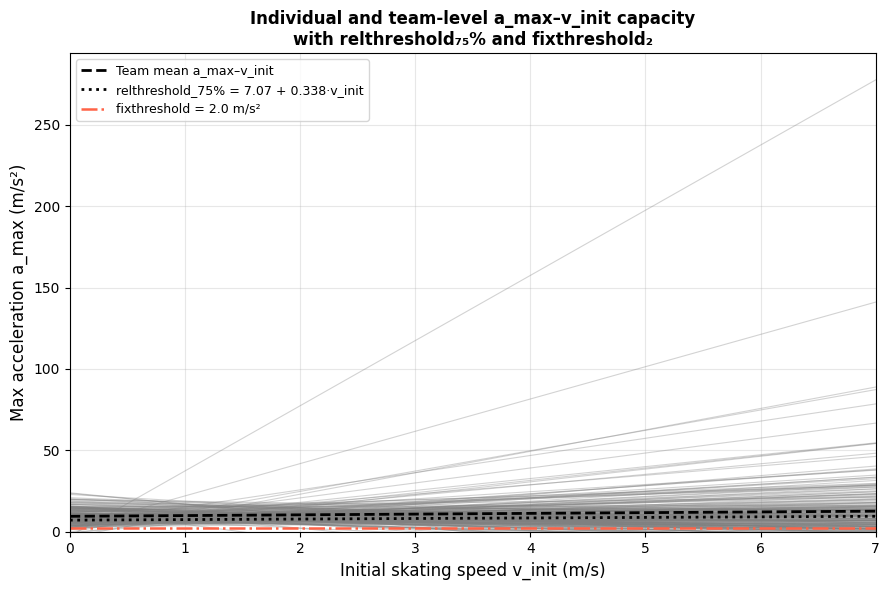

In [34]:
mean_a0 = models_df['intercept'].mean()
mean_a1 = models_df['slope'].mean()

rel_a0 = RELTHR_FRACTION * mean_a0
rel_a1 = RELTHR_FRACTION * mean_a1  # slope is negative

print('=' * 55)
print(f'Team mean a_max–v_init line: {mean_a0:.3f} + {mean_a1:.3f}·v_init')
print(f'relthreshold_75%:            {rel_a0:.3f} + {rel_a1:.3f}·v_init')
print('\nPaper comparison (Swiss NL team):')
print('  a_max line:    4.31 − 0.48·v_init')
print('  relthresh_75%: 3.23 − 0.365·v_init')
print('=' * 55)

def rel_thresh(vinit_ms):
    """Compute the team relthreshold_75% for the given initial speed (m/s)."""
    return rel_a0 + rel_a1 * np.asarray(vinit_ms)


# --- Visualization: individual + team lines + relthreshold ---
fig, ax = plt.subplots(figsize=(9, 6))

v_plot = np.linspace(0, 7, 200)

# Individual capacity lines (gray)
for _, row in models_df.iterrows():
    ax.plot(v_plot, row['intercept'] + row['slope'] * v_plot,
            color='gray', alpha=0.35, lw=0.8)

# Team mean line (black dashed)
ax.plot(v_plot, mean_a0 + mean_a1 * v_plot,
        color='black', lw=2, ls='--', label='Team mean a_max–v_init')

# relthreshold_75% (black dotted)
ax.plot(v_plot, rel_thresh(v_plot),
        color='black', lw=2, ls=':', label=f'relthreshold_75% = {rel_a0:.2f} + {rel_a1:.3f}·v_init')

# Fixed threshold
ax.axhline(FIX_THRESH_MS2, color='tomato', lw=1.8, ls='-.',
           label=f'fixthreshold = {FIX_THRESH_MS2} m/s²')

ax.axhline(0, color='black', lw=0.5, ls='-')
ax.set_xlabel('Initial skating speed v_init (m/s)', fontsize=12)
ax.set_ylabel('Max acceleration a_max (m/s²)', fontsize=12)
ax.set_title('Individual and team-level a_max–v_init capacity\nwith relthreshold₇₅% and fixthreshold₂',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 7)
ax.set_ylim(-0.5, None)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_capacity_lines.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Apply Both Thresholds and Compare

Classify each acceffort by:
- `fix_hi`: `amax ≥ 2 m/s²` (Fixthreshold)
- `rel_hi`: `amax ≥ relthreshold_75%(vinit)` (Relative threshold)

Report counts per **initial-speed band** and compare by **playing position**.

In [35]:
# Pull position labels from the shift_df cache
from build_shift_df import build_shift_df
_sdf = build_shift_df('../data')
_sdf['team_player'] = _sdf['Team'] + '_' + _sdf['Player_Id'].astype(str)
pos_lookup = (
    _sdf[['team_player', 'position']]
    .drop_duplicates('team_player')
    .set_index('team_player')['position']
)

accefforts['position'] = accefforts['team_player'].map(pos_lookup)

# Classify by threshold
accefforts['fix_hi'] = accefforts['amax'] >= FIX_THRESH_MS2
accefforts['rel_hi'] = accefforts['amax'] >= rel_thresh(accefforts['vinit'])

# Speed band labels
accefforts['speed_band'] = pd.cut(
    accefforts['vinit'],
    bins=BIN_EDGES_REPORT,
    labels=BIN_LABELS_REPORT,
    right=False
)

total = len(accefforts)
fix_n = accefforts['fix_hi'].sum()
rel_n = accefforts['rel_hi'].sum()

print(f'Total accefforts detected: {total:,}')
print(f'  fixthreshold_2 hits:     {fix_n:,}  ({100*fix_n/total:.1f}%)')
print(f'  relthreshold_75% hits:   {rel_n:,}  ({100*rel_n/total:.1f}%)')
if rel_n > 0:
    print(f'  Ratio fix/rel:           {fix_n/rel_n:.2f}×  (paper: ~1.89×)')

# Breakdown by speed band
band_tbl = accefforts.groupby('speed_band', observed=False).agg(
    n_total=('amax', 'count'),
    n_fix=('fix_hi', 'sum'),
    n_rel=('rel_hi', 'sum'),
).assign(
    pct_fix=lambda d: 100 * d['n_fix'] / d['n_total'].clip(lower=1),
    pct_rel=lambda d: 100 * d['n_rel'] / d['n_total'].clip(lower=1),
)
print('\nBreakdown by initial-speed band:')
print(band_tbl.round(1).to_string())


Loading cached shift_df from /Users/joeharter/repos/bdc-2026/stamina_models/shift_df.parquet
Total accefforts detected: 2,064
  fixthreshold_2 hits:     2,053  (99.5%)
  relthreshold_75% hits:   1,053  (51.0%)
  Ratio fix/rel:           1.95×  (paper: ~1.89×)

Breakdown by initial-speed band:
                 n_total  n_fix  n_rel  pct_fix  pct_rel
speed_band                                              
Very low\n(0–2)     1372   1367    738     99.6     53.8
Low\n(2–4)           447    443    193     99.1     43.2
Moderate\n(4–6)      209    207    103     99.0     49.3
Fast\n(>6)            36     36     19    100.0     52.8


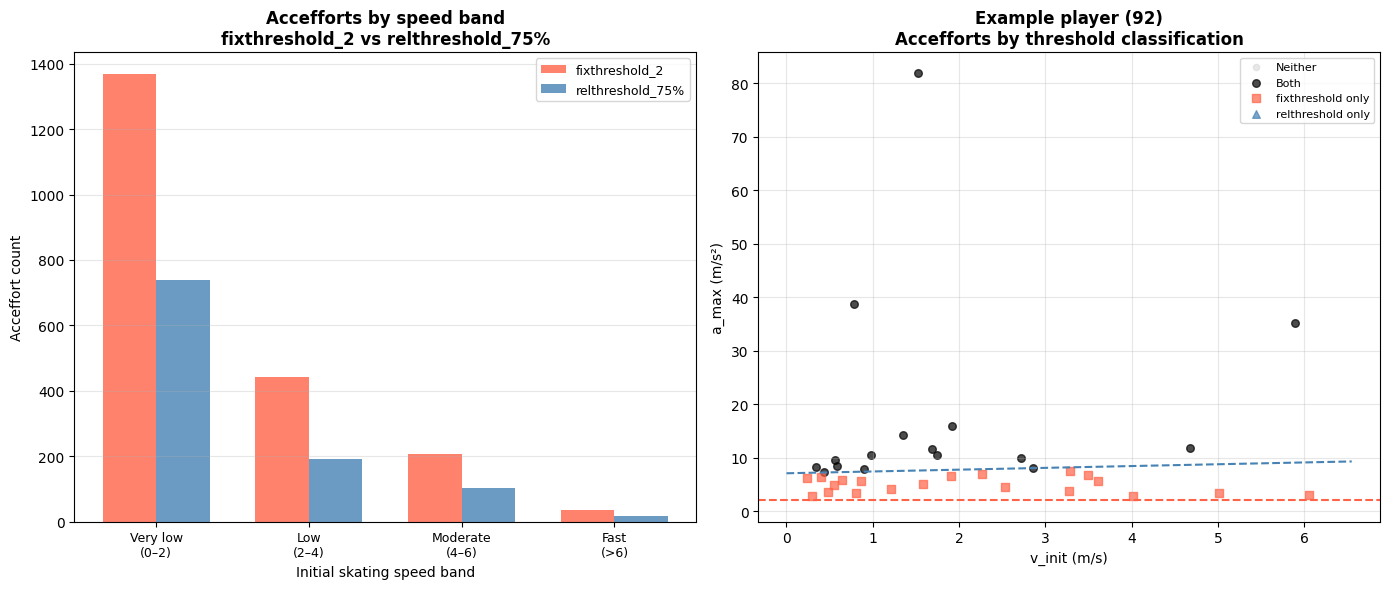

In [36]:
# --- Figure: 4-panel comparison -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bands   = BIN_LABELS_REPORT
x_pos   = np.arange(len(bands))
width   = 0.35

# Panel 1: counts by speed band
ax = axes[0]
vals_fix = band_tbl['n_fix'].values
vals_rel = band_tbl['n_rel'].values
bars_f = ax.bar(x_pos - width/2, vals_fix, width, label='fixthreshold_2',
                color='tomato', alpha=0.8)
bars_r = ax.bar(x_pos + width/2, vals_rel, width, label='relthreshold_75%',
                color='steelblue', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(bands, fontsize=9)
ax.set_xlabel('Initial skating speed band')
ax.set_ylabel('Acceffort count')
ax.set_title('Accefforts by speed band\nfixthreshold_2 vs relthreshold_75%', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 2: scatter with threshold lines — single player example
ax = axes[1]
example_p = (
    accefforts.groupby('team_player').size()
    .sort_values(ascending=False)
    .index[0]
)
eg = accefforts[accefforts['team_player'] == example_p]

# Colour by which threshold classifies it
both = eg['fix_hi'] & eg['rel_hi']
fix_only = eg['fix_hi'] & ~eg['rel_hi']
rel_only = ~eg['fix_hi'] & eg['rel_hi']
neither  = ~eg['fix_hi'] & ~eg['rel_hi']

ax.scatter(eg.loc[neither,  'vinit'], eg.loc[neither,  'amax'], s=20, alpha=0.5, color='lightgray',   label='Neither')
ax.scatter(eg.loc[both,     'vinit'], eg.loc[both,     'amax'], s=30, alpha=0.7, color='black',        label='Both', marker='o')
ax.scatter(eg.loc[fix_only, 'vinit'], eg.loc[fix_only, 'amax'], s=30, alpha=0.7, color='tomato',      label='fixthreshold only', marker='s')
ax.scatter(eg.loc[rel_only, 'vinit'], eg.loc[rel_only, 'amax'], s=30, alpha=0.7, color='steelblue',   label='relthreshold only', marker='^')

v_rng = np.linspace(0, eg['vinit'].max() + 0.5, 200)
ax.axhline(FIX_THRESH_MS2, color='tomato', lw=1.5, ls='--')
ax.plot(v_rng, rel_thresh(v_rng), color='steelblue', lw=1.5, ls='--')

ax.set_xlabel('v_init (m/s)')
ax.set_ylabel('a_max (m/s²)')
ax.set_title(f'Example player ({example_p.split("_")[-1]})\nAccefforts by threshold classification',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Positional Differences (relthreshold)

The paper found forwards performed significantly more relthreshold accefforts initiated from **moderate** (4–6 m/s) and **fast** (>6 m/s) speeds (very large Cohen's d = 2.95 / 2.74), consistent with their typical actions (forechecking, breakouts, rushes).

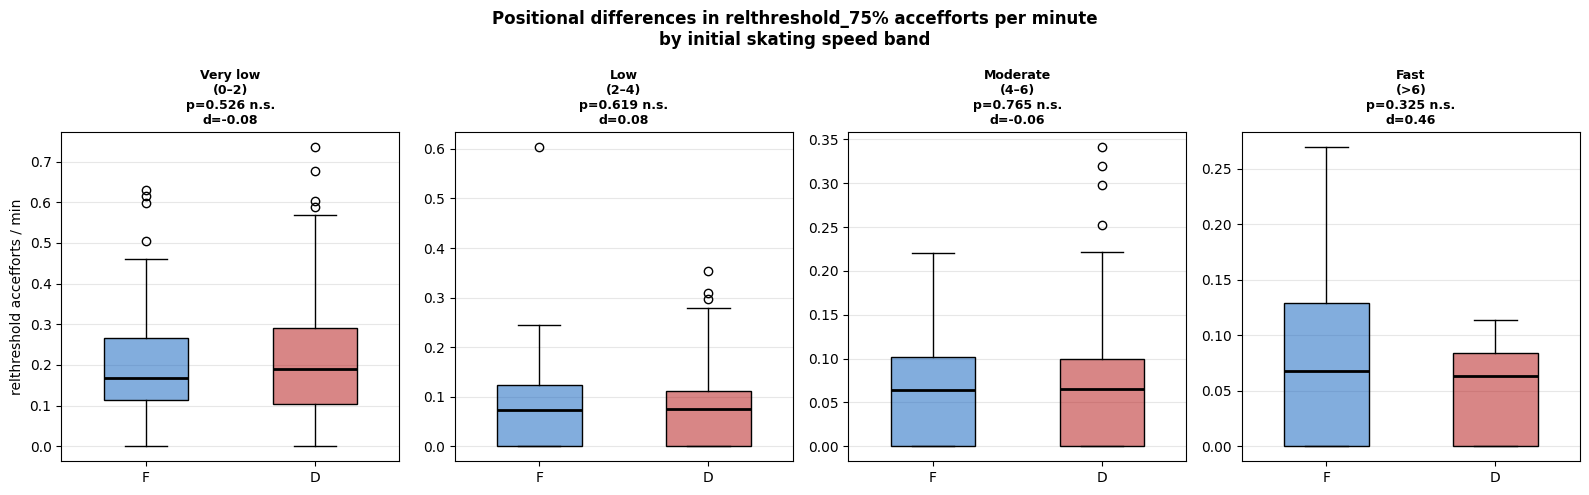

relthreshold_75% accefforts/min — mean ± SD:
                           mean    std
position speed_band                   
D        Very low\n(0–2)  0.208  0.143
         Low\n(2–4)       0.072  0.075
         Moderate\n(4–6)  0.066  0.074
         Fast\n(>6)       0.047  0.045
F        Very low\n(0–2)  0.197  0.142
         Low\n(2–4)       0.078  0.099
         Moderate\n(4–6)  0.062  0.065
         Fast\n(>6)       0.083  0.101


In [ ]:

# Per-player per-game summary for positional comparison
# Drop rows with no position mapping (players absent from shift_df)
accefforts_pos = accefforts.dropna(subset=['position'])

player_game = (
    accefforts_pos
    .groupby(['team_player', 'Game', 'position', 'speed_band'], observed=True)
    .agg(
        fix_n=('fix_hi', 'sum'),
        rel_n=('rel_hi', 'sum'),
        n_total=('amax', 'count'),
    )
    .reset_index()
)

# Also compute total on-ice minutes per player-game (from tracking)
ice_min_pgame = (
    players
    .groupby(['team_player', 'Game'])
    .size()
    .reset_index(name='n_frames')
    .assign(ice_min=lambda d: d['n_frames'] / FPS / 60)
[['team_player', 'Game', 'ice_min']]
)

player_game = player_game.merge(ice_min_pgame, on=['team_player', 'Game'], how='left')
player_game['rel_per_min'] = player_game['rel_n'] / player_game['ice_min'].clip(lower=0.1)
player_game['fix_per_min'] = player_game['fix_n'] / player_game['ice_min'].clip(lower=0.1)

# Boxplot: relthreshold accefforts/min by position and speed band
fig, axes = plt.subplots(1, len(BIN_LABELS_REPORT), figsize=(16, 5), sharey=False)

for ax, band in zip(axes, BIN_LABELS_REPORT):
    sub = player_game[player_game['speed_band'] == band]
    data_f = sub.loc[sub['position'] != 'D', 'rel_per_min'].dropna()
    data_d = sub.loc[sub['position'] == 'D', 'rel_per_min'].dropna()

    bp = ax.boxplot([data_f, data_d], labels=['F', 'D'],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
    bp['boxes'][0].set_facecolor(POS_COLORS['F'] + '88')
    bp['boxes'][1].set_facecolor(POS_COLORS['D'] + '88')

    # Significance annotation
    if len(data_f) > 1 and len(data_d) > 1:
        _, pval = stats.ttest_ind(data_f, data_d, equal_var=False)
        d_cohen = (data_f.mean() - data_d.mean()) / (
            np.sqrt((data_f.std()**2 + data_d.std()**2) / 2)
        ) if (data_f.std() + data_d.std()) > 0 else 0
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
        ax.set_title(f'{band}\np={pval:.3f} {star}\nd={d_cohen:.2f}', fontsize=9, fontweight='bold')
    else:
        ax.set_title(f'{band}', fontsize=9, fontweight='bold')

    ax.set_ylabel('relthreshold accefforts / min' if ax == axes[0] else '')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Positional differences in relthreshold_75% accefforts per minute\nby initial skating speed band',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_positional_differences.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
pos_summary = (
    player_game
    .groupby(['position', 'speed_band'], observed=True)['rel_per_min']
    .agg(['mean', 'std'])
    .round(3)
)
print('relthreshold_75% accefforts/min — mean ± SD:')
print(pos_summary)


## Step 6 — Per-Shift Acceffort Rate for Fatigue Analysis

Join accefforts back to shift boundaries to compute **relthreshold accefforts per minute** as a per-shift feature.  This can be used as a dependent variable in the same fatigue-model notebooks (01–06) to ask: *Does the rate of high-intensity acceleration efforts drop within a game as a function of cumulative ice time?*

In [38]:

# Build a (Game, Period_int, frame_id) → elapsed_s lookup.
# frame_id is extracted from the image-file suffix and is NOT globally unique —
# the same number can appear in different games/periods. Keying only on frame_id
# would map efforts to the wrong elapsed_s. Use all three columns.
fid_elapsed = (
    players[['Game', 'Period_int', 'frame_id', 'elapsed_s']]
    .drop_duplicates(['Game', 'Period_int', 'frame_id'])
)

print(f'Frame → elapsed lookup rows: {len(fid_elapsed):,}')
print(f'Elapsed range: {fid_elapsed["elapsed_s"].min():.0f} – {fid_elapsed["elapsed_s"].max():.0f} s')
print(f'\n_sdf shift_df shape: {_sdf.shape}')
print(f'_sdf columns: {list(_sdf.columns[:12])}')


Frame → elapsed lookup rows: 957,026
Elapsed range: 0 – 1200 s

_sdf shift_df shape: (6218, 33)
_sdf columns: ['Game', 'Team', 'Period_int', 'Player_Id', 'shift_number', 'shift_start_s', 'shift_end_s', 'shift_duration_s', 'rest_time_s', 'is_first_shift', 'n_frames', 'ice_min']


In [39]:

# Rebuild acceffort detection WITH start_frame_id for time-stamping
def detect_accefforts_timed(player_df, fps=30,
                             gap_frames=150,
                             dip_thresh=DIP_THRESH_MS2,
                             dip_frames=DIP_FRAMES,
                             min_frames=MIN_FRAMES,
                             min_vdelta=MIN_VDELTA_MS):
    """Like detect_all_accefforts but also returns start_frame_id for timing."""
    df = player_df.sort_values('frame_id').reset_index(drop=True)
    speed  = df['speed_ms'].values
    accel  = df['accel_ms2'].values
    frame_ids = df['frame_id'].values
    n = len(accel)

    gaps = np.diff(frame_ids)
    break_pts = np.where(gaps > gap_frames)[0] + 1
    seg_starts = np.concatenate([[0], break_pts])
    seg_ends   = np.concatenate([break_pts, [n]])

    all_efforts = []
    for s_idx, e_idx in zip(seg_starts, seg_ends):
        seg_speed  = speed[s_idx:e_idx]
        seg_accel  = accel[s_idx:e_idx]
        seg_frames = frame_ids[s_idx:e_idx]
        n_seg = len(seg_accel)
        if n_seg < min_frames:
            continue

        i = 0
        while i < n_seg:
            while i < n_seg and seg_accel[i] <= 0:
                i += 1
            if i >= n_seg:
                break

            effort_start  = i
            vinit         = float(seg_speed[i])
            start_fid     = int(seg_frames[i])

            j = i + 1
            in_dip, dip_start_idx, dip_count = False, None, 0

            while j < n_seg and seg_accel[j] > 0:
                if seg_accel[j] < dip_thresh:
                    if not in_dip:
                        dip_start_idx = j; dip_count = 1; in_dip = True
                    else:
                        dip_count += 1
                else:
                    if in_dip and dip_count > dip_frames:
                        # Split: emit first half
                        end1 = dip_start_idx
                        if (end1 - effort_start) >= min_frames:
                            amax_v = float(seg_accel[effort_start:end1].max())
                            vd     = float(seg_speed[min(end1, n_seg-1)]) - vinit
                            if vd >= min_vdelta:
                                all_efforts.append({'vinit': vinit, 'amax': amax_v,
                                                    'aduration': (end1 - effort_start)/fps,
                                                    'vdelta': vd, 'start_frame_id': start_fid})
                        effort_start = j
                        vinit        = float(seg_speed[j - 1])
                        start_fid    = int(seg_frames[j])
                    in_dip = False; dip_start_idx = None; dip_count = 0
                j += 1

            # Emit final portion
            end_final = dip_start_idx if (in_dip and dip_count > dip_frames) else j
            if (end_final - effort_start) >= min_frames:
                amax_v = float(seg_accel[effort_start:end_final].max())
                vd     = float(seg_speed[min(end_final, n_seg-1)]) - vinit
                if vd >= min_vdelta:
                    all_efforts.append({'vinit': vinit, 'amax': amax_v,
                                        'aduration': (end_final - effort_start)/fps,
                                        'vdelta': vd, 'start_frame_id': start_fid})
            i = j if j > effort_start else effort_start + 1

    return all_efforts


timed_records = []
for (game, period, team_player), grp in players.groupby(
        ['Game', 'Period_int', 'team_player'], observed=True):
    efforts = detect_accefforts_timed(grp)
    for ef in efforts:
        timed_records.append({'Game': game, 'Period_int': period,
                              'team_player': team_player, **ef})

timed_efforts = pd.DataFrame(timed_records)
timed_efforts['rel_hi'] = timed_efforts['amax'] >= rel_thresh(timed_efforts['vinit'])
timed_efforts['fix_hi'] = timed_efforts['amax'] >= FIX_THRESH_MS2

# Join elapsed_s via (Game, Period_int, frame_id) — frame_id alone is not unique across games
timed_efforts = timed_efforts.merge(
    fid_elapsed.rename(columns={'frame_id': 'start_frame_id'}),
    on=['Game', 'Period_int', 'start_frame_id'],
    how='left',
)

n_nan = timed_efforts['elapsed_s'].isna().sum()
print(f'Timed efforts:        {len(timed_efforts):,}')
print(f'elapsed_s NaN:        {n_nan:,}  ({100*n_nan/max(len(timed_efforts),1):.1f}%)')
print(f'elapsed_s range:      {timed_efforts["elapsed_s"].min():.0f} – {timed_efforts["elapsed_s"].max():.0f} s')


Timed efforts:        2,064
elapsed_s NaN:        6  (0.3%)
elapsed_s range:      0 – 1199 s


In [40]:
# Use _sdf (from build_shift_df) which already has shift_start_s, shift_end_s, ice_min
# and the correctly-constructed Game and Period_int keys.
shift_lookup = _sdf[['Game', 'Period_int', 'team_player',
                       'shift_start_s', 'shift_end_s', 'ice_min',
                       'cumulative_ice_min_before', 'rest_time_s',
                       'position', 'score_diff', 'is_first_shift']].copy()

# Cross-join timed efforts to shift windows by player, then filter by time
effort_timed_clean = timed_efforts.dropna(subset=['elapsed_s'])
merged = effort_timed_clean.merge(
    shift_lookup,
    on=['Game', 'Period_int', 'team_player'],
    how='inner',
)
merged = merged[
    (merged['elapsed_s'] >= merged['shift_start_s']) &
    (merged['elapsed_s'] <= merged['shift_end_s'] + 2)
]

# Count per shift
shift_effort_counts = merged.groupby(
    ['Game', 'Period_int', 'team_player', 'shift_start_s', 'shift_end_s'], observed=True
).agg(
    rel_accefforts=('rel_hi', 'sum'),
    fix_accefforts=('fix_hi', 'sum'),
    total_accefforts=('amax', 'count'),
).reset_index()

# Left-join to all shifts (zeros for shifts with no detected efforts)
shift_effort_full = shift_lookup.merge(
    shift_effort_counts,
    on=['Game', 'Period_int', 'team_player', 'shift_start_s', 'shift_end_s'],
    how='left'
).fillna({'rel_accefforts': 0, 'fix_accefforts': 0, 'total_accefforts': 0})

shift_effort_full['rel_accefforts_pm'] = (
    shift_effort_full['rel_accefforts'] / shift_effort_full['ice_min'].clip(lower=0.1)
)

print(f'Shifts with ≥1 rel acceffort: '
      f'{(shift_effort_full["rel_accefforts"] > 0).sum():,} / {len(shift_effort_full):,}')
print('\nrel_accefforts_pm summary:')
print(shift_effort_full['rel_accefforts_pm'].describe().round(3))


Shifts with ≥1 rel acceffort: 935 / 6,218

rel_accefforts_pm summary:
count    6218.000
mean        0.281
std         0.752
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         5.538
Name: rel_accefforts_pm, dtype: float64


## Step 7 — Fatigue: Does relthreshold Rate Decline Within a Game?

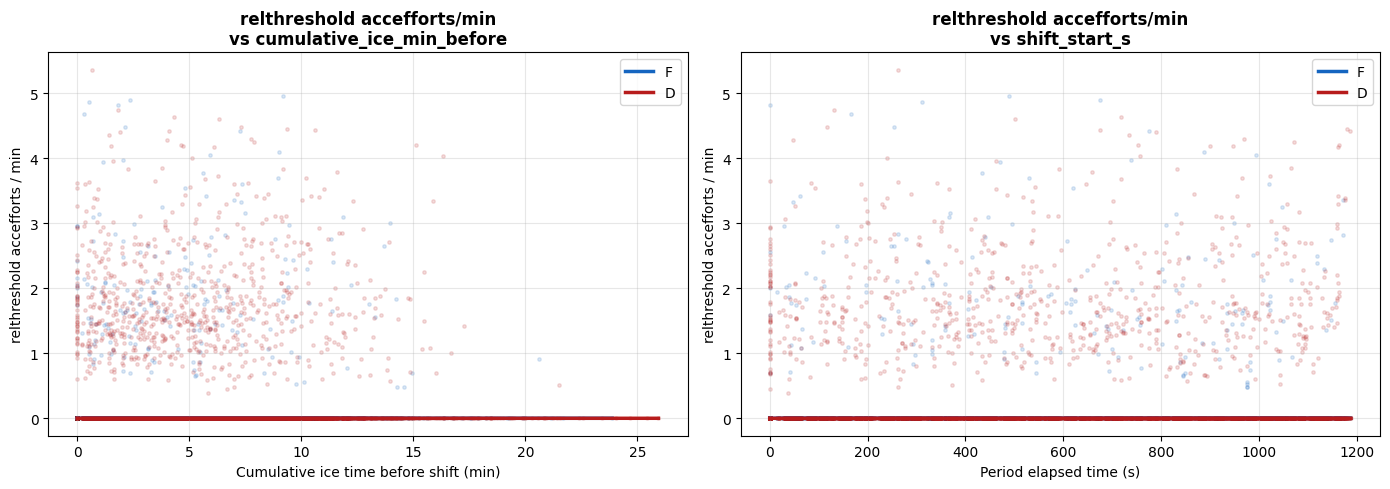

                     Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:      0.002     
Dependent Variable:    rel_accefforts_pm  AIC:                 13652.3868
Date:                  2026-03-11 17:26   BIC:                 13712.7675
No. Observations:      6057               Log-Likelihood:      -6817.2   
Df Model:              8                  F-statistic:         2.586     
Df Residuals:          6048               Prob (F-statistic):  0.00809   
R-squared:             0.003              Scale:               0.55690   
-------------------------------------------------------------------------
                           Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-------------------------------------------------------------------------
Intercept                  0.3697   0.0321 11.5198 0.0000  0.3068  0.4326
C(Period_int)[T.2]         0.0412   0.0292  1.4117 0.1581 -0.0160  0.0983
C(Period_int)[T.3]         0.0839   0.0443  1.8913 0.0586 -

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf
from build_shift_df import PREDICTORS

model_df = shift_effort_full.dropna(
    subset=['rel_accefforts_pm', 'cumulative_ice_min_before', 'rest_time_s', 'ice_min', 'position']
).copy()
model_df = model_df[model_df['ice_min'] > 0.2].copy()
model_df['is_forward']    = (model_df['position'] != 'D').astype(int)\n
model_df['is_first_int']  = model_df['is_first_shift'].astype(int)
model_df['rest_time_min'] = model_df['rest_time_s'] / 60
model_df['shift_duration_min'] = model_df['ice_min'].copy()  # ice_min already in minutes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, xlabel in [
    (axes[0], 'cumulative_ice_min_before', 'Cumulative ice time before shift (min)'),
    (axes[1], 'shift_start_s',            'Period elapsed time (s)'),
]:
    for pos, color in POS_COLORS.items():
        sub = model_df[model_df['position'] == pos]
        if len(sub) < 10:
            continue
        x = sub[col].values
        y = sub['rel_accefforts_pm'].values
        order = np.argsort(x)
        sm = lowess(y[order], x[order], frac=0.4, return_sorted=True)
        ax.scatter(x, y, s=6, alpha=0.15, color=color)
        ax.plot(sm[:, 0], sm[:, 1], color=color, lw=2.5, label=pos)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('relthreshold accefforts / min')
    ax.set_title(f'relthreshold accefforts/min\nvs {col}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_fatigue_lowess.png', dpi=150, bbox_inches='tight')
plt.show()

# OLS: does fatigue predict relthreshold acceffort rate?
try:
    ols = smf.ols(f'rel_accefforts_pm ~ {PREDICTORS}', data=model_df).fit()
    print(ols.summary2())
    print(f'\nR² = {ols.rsquared:.4f}   adj-R² = {ols.rsquared_adj:.4f}')
    cum_ice_coef = ols.params.get('cumulative_ice_min_before', np.nan)
    cum_ice_pval = ols.pvalues.get('cumulative_ice_min_before', np.nan)
    print(f'\ncumulative_ice_min_before: coef={cum_ice_coef:.4f}  p={cum_ice_pval:.4f}')
except Exception as e:
    print(f'OLS failed: {e}')


## Summary

| Item | Value |
|------|-------|
| Detection method | Zero-crossing with dip rule (8 frames, 0.5 m/s²) |
| Minimum duration | 1.15 s (35 frames @ 30 fps) |
| Minimum speed gain | 1.0 m/s (3.6 km/h) |
| Team relthreshold_75% | derived from data above |
| Paper comparison | 3.23 − 0.365·v_init m/s² (N=17, 10 games, Swiss NL) |

### Key findings to document
- Does the fix/rel ratio match the paper's ~89% excess for fixthreshold?
- Do forwards show more moderate/fast accefforts than defensemen?
- Does cumulative ice time predict a declining relthreshold rate?

### Limitations to note
- Our rink uses optical/camera-based tracking (not wearable UWB), position-derived acceleration is noisier.
- SavGol window = 11 frames (shorter than the paper's Butterworth + Kalman processing).
- Some players may have fewer games → less stable individual capacity lines.
- Player identity is jersey number (string); could mismatch across games if jersey reused.